In [ ]:
from pathlib import Path
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from mpl_toolkits.mplot3d import proj3d
from mpl_toolkits.mplot3d.axes3d import Axes3D
from PIL import Image

In [3]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
GEBCO_PATH = list(Path(DATA_DIR / "GEBCO/").glob("*.nc"))

In [4]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
bathymetry = xr.open_mfdataset(GEBCO_PATH)

In [5]:
def find_nearest(
    array,  # noqa: ANN001
    value,  # noqa: ANN001
) -> int | None:
    """Find index of nearest value in array.

    Args:
        array (array): array to search
        value (scalar): value to find nearest to

    Returns:
        int or None: index of nearest value, or None if all values are NaN

    """
    if np.all(np.isnan(array)):
        return None
    array = np.asarray(array)
    idx = int(np.nanargmin(np.abs(array - value)))
    return idx


def haversine(
    lon1: float | np.ndarray | xr.DataArray,
    lat1: float | np.ndarray | xr.DataArray,
    lon2: float | np.ndarray | xr.DataArray,
    lat2: float | np.ndarray | xr.DataArray,
) -> float | np.ndarray | xr.DataArray:
    """Calculate the great circle distance between two points on the earth (specified in decimal degrees).

    Args:
        lon1 (scalar): longitude of first point
        lat1 (scalar): latitude of first point
        lon2 (scalar): longitude of second point
        lat2 (scalar): latitude of second point

    Returns:
        scalar: distance in km between (lon1, lat1) and (lon2, lat2)

    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

In [57]:
bathymetry = xr.open_mfdataset(GEBCO_PATH)
bathymetry = bathymetry.isel({"lat": find_nearest(bathymetry["lat"].values, 44.66)})
bathymetry = bathymetry.interp({"lon": np.linspace(-130, -123, int(1e6))})
topo = bathymetry["elevation"].squeeze().values
coast = bathymetry.isel({"lon": np.argmin(np.abs(topo))})


bathymetry = bathymetry.interp({"lon": np.linspace(-130, -123, int(1e4))})

In [58]:
long = bathymetry.lon.values
lat = bathymetry.lat.values

meters = np.nan * np.zeros(len(long))
for i, lo in enumerate(long):
    meters[i] = haversine(long[0], lat, lo, lat) - haversine(
        long[0],
        lat,
        coast.lon.values,
        lat,
    )

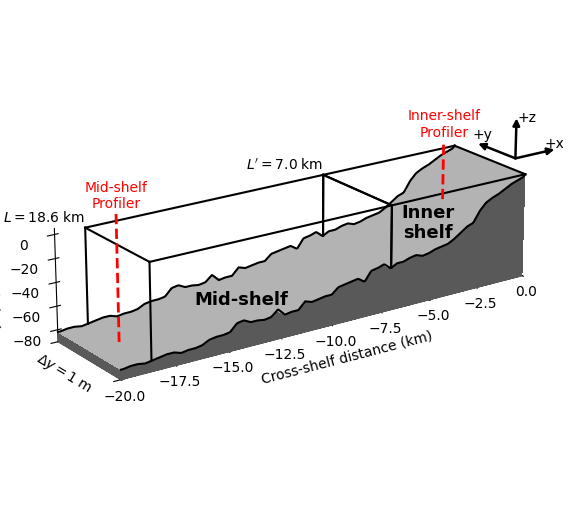

In [65]:
fig, ax = plt.subplots(figsize=(10, 6.5), subplot_kw={"projection": "3d"})
ax = cast("Axes3D", ax)

# Camera: above and from the west
ax.view_init(elev=20, azim=235)
ax.set_proj_type("persp")

# colors
wall_color = "0.35"

# profiler locations
mid_shelf_profiler_km = -18.6
inner_shelf_profiler_km = -2.5
mid_inner_division_km = -7.0

# options for axis arrows and text labels
axis_len = 0.08
arrow_style = {"arrowstyle": "-|>", "color": "k", "lw": 1.8, "shrinkA": 0, "shrinkB": 0}
text_style = {"color": "k", "fontsize": 10, "va": "center"}

long = bathymetry["lon"].values
lat = float(bathymetry["lat"].values)
bathymetry_arr = np.asarray(bathymetry["elevation"].squeeze())

# distance from the westernmost point to each lon
dist_km = haversine(long[0], lat, long, lat)
coast_km = haversine(long[0], lat, float(coast["lon"].values), lat)
# type stuff
dist_km = cast("np.ndarray", dist_km)
coast_km = cast("float", coast_km)
# compute cross-shelf distance from coast in km
cross_shelf_km: np.ndarray = dist_km - coast_km

# along-shelf distance of 1 m
along_shelf = np.linspace(0, 1, 300)
xx, yy = np.meshgrid(cross_shelf_km, along_shelf)
zz = np.tile(bathymetry_arr, (along_shelf.size, 1))

# mask for shelf window
x_min, x_max = -20.0, 0.0
mask = (xx <= x_max) & (xx >= x_min)
zz_masked = np.where(mask, zz, np.nan)

# limits for z axis
z_surface = 0.0
z_floor = np.nanmin(zz_masked) * 1.1

# cross shelf distance and bathymetry arrays masked to the shelf window
cross_shelf_km_masked = cross_shelf_km[(cross_shelf_km >= x_min) & (cross_shelf_km <= x_max)]
bathymetry_masked = bathymetry_arr[(cross_shelf_km >= x_min) & (cross_shelf_km <= x_max)]

# add 2nd array dimensions for plotting in y-direction
x_w = np.vstack([cross_shelf_km_masked, cross_shelf_km_masked])
z_w = np.vstack([bathymetry_masked, np.full_like(bathymetry_masked, z_floor)])
y_w0 = np.zeros_like(x_w)
y_w1 = np.ones_like(x_w)

# y=0 wall
ax.plot_surface(
    x_w,
    y_w0,
    z_w,
    linewidth=0,
    antialiased=False,
    shade=False,
    color=wall_color,
    zorder=10,
)
# y=1 wall
ax.plot_surface(
    x_w,
    y_w1,
    z_w,
    linewidth=0,
    antialiased=False,
    shade=False,
    color=wall_color,
    zorder=10,
)
# bottom wall
ax.plot_surface(
    xx,
    yy,
    np.where(mask, z_floor, np.nan),
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    color=wall_color,
    zorder=10,
)
# middle light gray bathymetry surface
ax.plot_surface(
    xx,
    yy,
    zz_masked,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    color="0.7",
    alpha=1,
    zorder=20,
)

# bottom edge lines along bathymetry at y=0 and y=1
ax.plot(
    cross_shelf_km_masked,
    np.zeros_like(cross_shelf_km_masked),
    bathymetry_masked,
    color="k",
    linewidth=1.5,
    zorder=20,
)
ax.plot(
    cross_shelf_km_masked,
    np.ones_like(cross_shelf_km_masked),
    bathymetry_masked,
    color="k",
    linewidth=1.5,
    zorder=20,
)


def _plot_box_region(
    x0: float,
    x1: float,
    cross_shelf_km: np.ndarray,
    bathymetry_arr: np.ndarray,
    z_surface: float,
    edge_color: str = "k",
) -> None:
    box_mask = (cross_shelf_km >= x0) & (cross_shelf_km <= x1)
    x_box = cross_shelf_km[box_mask]
    if x_box.size < 2:
        return

    # Surface rectangle
    ax.plot([x0, x1], [0, 0], [z_surface, z_surface], color=edge_color, linewidth=1.5, zorder=9)
    ax.plot([x0, x1], [1, 1], [z_surface, z_surface], color=edge_color, linewidth=1.5, zorder=9)
    ax.plot([x0, x0], [0, 1], [z_surface, z_surface], color=edge_color, linewidth=1.5, zorder=9)
    ax.plot([x1, x1], [0, 1], [z_surface, z_surface], color=edge_color, linewidth=1.5, zorder=9)

    # Vertical edges at x0 and x1 down to bathymetry
    z_x0 = float(bathymetry_arr[int(np.nanargmin(np.abs(cross_shelf_km - x0)))])
    z_x1 = float(bathymetry_arr[int(np.nanargmin(np.abs(cross_shelf_km - x1)))])
    ax.plot([x0, x0], [0, 0], [z_surface, z_x0], color=edge_color, linewidth=1.5, zorder=9)
    ax.plot([x0, x0], [1, 1], [z_surface, z_x0], color=edge_color, linewidth=1.5, zorder=9)
    ax.plot([x1, x1], [0, 0], [z_surface, z_x1], color=edge_color, linewidth=1.5, zorder=9)
    ax.plot([x1, x1], [1, 1], [z_surface, z_x1], color=edge_color, linewidth=1.5, zorder=9)


# region 1 - midshelf
_plot_box_region(mid_shelf_profiler_km, mid_inner_division_km, cross_shelf_km_masked, bathymetry_masked, z_surface)

# region 2 - inner shelf
_plot_box_region(mid_inner_division_km, 0, cross_shelf_km_masked, bathymetry_masked, z_surface)

# Labels for box extents
ax.text3D(
    mid_shelf_profiler_km,
    1.0,
    5.0,
    f"$L={-mid_shelf_profiler_km} \\; \\mathsf{{km}}$",
    color="k",
    fontsize=10,
    ha="right",
    zorder=200,
)
ax.text3D(
    mid_inner_division_km,
    1.0,
    5.0,
    f"$L'={-mid_inner_division_km} \\; \\mathsf{{km}}$",
    color="k",
    fontsize=10,
    ha="right",
    zorder=200,
)

# Region labels
ax.text3D(-12.8, 0.5, -75, "Mid-shelf", color="k", fontsize=13, fontweight="bold", ha="center", zorder=200)
ax.text3D(-3.25, 0.5, -57, "Inner\nshelf", color="k", fontsize=13, fontweight="bold", ha="center", zorder=200)


def _project_to_axes_fraction(ax: Axes3D, x: float, y: float, z: float) -> np.ndarray:
    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    x_disp, y_disp = ax.transData.transform((x2, y2))
    return ax.transAxes.inverted().transform((x_disp, y_disp))


def _draw_axis(
    ax: Axes3D,
    vec_2d: np.ndarray,
    origin_2d: np.ndarray,
    axis_len: float,
    label: str,
    offset: np.ndarray,
    text_style: dict,
    arrow_style: dict,
) -> None:
    norm = np.linalg.norm(vec_2d)
    if norm == 0:
        return
    unit = vec_2d / norm
    end = origin_2d + unit * axis_len
    ax.annotate(
        "",
        xy=(end[0], end[1]),
        xytext=(origin_2d[0], origin_2d[1]),
        xycoords="axes fraction",
        arrowprops=arrow_style,
        zorder=100,
    )
    label_pos = end + offset
    ax.text2D(label_pos[0], label_pos[1], label, transform=ax.transAxes, zorder=200, **text_style)


# create axis vectors in 2D figure coordinates at the 3D origin point
origin_3d = (x_min + 100.0, -0.1, z_surface + 1.0)
origin_2d = _project_to_axes_fraction(ax, *origin_3d)
dx_2d = _project_to_axes_fraction(ax, origin_3d[0] + 1.0, origin_3d[1], origin_3d[2]) - origin_2d
dy_2d = _project_to_axes_fraction(ax, origin_3d[0], origin_3d[1] + 1.0, origin_3d[2]) - origin_2d
dz_2d = _project_to_axes_fraction(ax, origin_3d[0], origin_3d[1], origin_3d[2] + 1.0) - origin_2d

# draw axis vectors with labels
_draw_axis(ax, dx_2d, origin_2d, axis_len, "+x", np.array([-0.020, 0.012]), text_style, arrow_style)
_draw_axis(ax, dy_2d, origin_2d, axis_len, "+y", np.array([-0.012, 0.018]), text_style, arrow_style)
_draw_axis(ax, dz_2d, origin_2d, axis_len, "+z", np.array([0.002, 0.002]), text_style, arrow_style)

# axis styling
ax.set_xlim(-20, 0)
ax.set_ylim(0, 1)
ax.set_zlim(z_floor, 5)
ax.grid(visible=False)
ax.set_box_aspect((2.5, 0.6, 0.6))

# remove tick marks and numerical values on y axis
ax.set_yticks([0, 1])
ax.set_yticklabels(["", ""])

# make panes (backgrounds) transparent on all axes
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# set axis labels
ax.set_xlabel("Cross-shelf distance (km)", labelpad=20)
ax.set_ylabel("$\\Delta y = \\mathsf{1 \\; m}$", labelpad=-10)
ax.set_zlabel("Depth (m)", labelpad=3)

# vertical lines at midshelf and inner-shelf profiler locations
mid_shelf_profiler_z = float(bathymetry_arr[int(np.nanargmin(np.abs(cross_shelf_km + 18.6)))])
ax.plot(
    [-18.6, -18.6],
    [0.5, 0.5],
    [mid_shelf_profiler_z, 25],
    linestyle="--",
    linewidth=2,
    color="r",
    zorder=30,
)
inner_shelf_profiler_z = float(bathymetry_arr[int(np.nanargmin(np.abs(cross_shelf_km + 2.5)))])
ax.plot(
    [-2.5, -2.5],
    [0.5, 0.5],
    [inner_shelf_profiler_z, 25],
    linestyle="--",
    linewidth=2,
    color="r",
    zorder=30,
)

# profiler labels
ax.text3D(-18.6, 0.5, 30, "Mid-shelf\nProfiler", color="r", fontsize=10, ha="center", zorder=200)
ax.text3D(-2.5, 0.5, 30, "Inner-shelf\nProfiler", color="r", fontsize=10, ha="center", zorder=200)

plt.savefig(FIGURES_DIR / "control_volume_3d.png", dpi=300, bbox_inches="tight", pad_inches=0.5)

In [66]:
# now open the saved figure and crop to just the control volume region (removing excess white space above and below)
# couldn't find a good way to do this in matplotlib directly, so using PIL to crop the saved image
img = Image.open(FIGURES_DIR / "control_volume_3d.png")

width, height = img.size
img = img.crop((0, height * 0.2, width, height * 0.8))

# examine the cropped image
img.show()

# save the cropped image
img.save(FIGURES_DIR / "control_volume_3d_cropped.png", dpi=(300, 300))